# Setup

In [6]:
%load_ext autoreload
%autoreload 2

# %matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import dunetrg.data.workspace as workspace
import dunetrg.analysis.snn as snn

from rich import print


# Data

In [8]:
import dunetrg.data.datacatalogue as dsl

dataset_name = 'radbkg'
datasets = dsl.load('vd/1x8x14/old_detsim', dataset_name)
rad_ws=datasets[dataset_name]


Loading radbkg

Dataset 'radbkg': 100 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x14ref'},
    'mctruth_blockid_map': [
        [28, 'Rn222ChainFromPo218GenInUpperMesh1x8x14'],
        [27, 'Rn220ChainFromPb212GenInUpperMesh1x8x14'],
        [26, 'Kr85GenInLAr'],
        [25, 'Rn222ChainFromBi210GenInUpperMesh1x8x14'],
        [24, 'U238ChainGenInAnode'],
        [23, 'K40GenInCathode'],
        [22, 'K42From42ArGenInUpperMesh1x8x14'],
        [21, 'Th232ChainGenInCathode'],
        [20, 'CavernNGammasAtLAr1x8x14'],
        [19, 'Rn222ChainRn222GenInLAr'],
        [18, 'U238ChainGenInCathode'],
        [17, 'K40GenInAnode'],
        [16, 'Rn220ChainPb212GenInLAr'],
        [15, 'foamGammasAtLAr1x8x14'],
        [14, 'Rn222ChainFromPb214GenInUpperMesh1x8x14'],
        [13, 'K42From42ArGenInLAr'],
        [12, 'Rn222ChainGenInPDS'],
        [11, 'Ar42GenInLAr'],
        [10, 'CavernwallGammasAtLAr1x8x14'],
        [9, 'Rn222ChainPb210GenInLAr'],
        [8, 'Ar39GenInLAr'],
        [7, 'Rn222ChainPb214GenInLAr'],
        [6, 'Rn222ChainFromPb210GenInUpperMesh1x8x14'],
        [5, 'Rn222ChainPo218GenInLAr'],
        [4, 'CavernwallNeutronsAtLAr1x8x14'],
        [3, 'Rn222ChainFromBi214GenInUpperMesh1x8x14'],
        [2, 'CryostatNGammasAtLAr1x8x14'],
        [1, 'Th232ChainGenInAnode'],
        [0, 'Rn222ChainBi214GenInLAr']
    ],
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 45,
            'threshold_tpg_plane1': 45,
            'threshold_tpg_plane2': 45,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    },
    'detector_properties': {'readout_window': 8500}
}

# Radiologicals

In [9]:
from dunetrg.analysis.viz.mc import MCPlotter

mcp = MCPlotter(datasets['radbkg'])

#### Simulated time

In [10]:
print(f'{mcp.simulated_mc_time():f} seconds')

0.850000 seconds

## List of generators

In [11]:
mcp.make_generators_table()

             Background generators              
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━┓
┃ generator name                          ┃ id ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━┩
│ Rn222ChainFromPo218GenInUpperMesh1x8x14 │ 28 │
│ Rn220ChainFromPb212GenInUpperMesh1x8x14 │ 27 │
│ Kr85GenInLAr                            │ 26 │
│ Rn222ChainFromBi210GenInUpperMesh1x8x14 │ 25 │
│ U238ChainGenInAnode                     │ 24 │
│ K40GenInCathode                         │ 23 │
│ K42From42ArGenInUpperMesh1x8x14         │ 22 │
│ Th232ChainGenInCathode                  │ 21 │
│ CavernNGammasAtLAr1x8x14                │ 20 │
│ Rn222ChainRn222GenInLAr                 │ 19 │
│ U238ChainGenInCathode                   │ 18 │
│ K40GenInAnode                           │ 17 │
│ Rn220ChainPb212GenInLAr                 │ 16 │
│ foamGammasAtLAr1x8x14                   │ 15 │
│ Rn222ChainFromPb214GenInUpperMesh1x8x14 │ 14 │
│ K42From42ArGenInLAr                     │ 13 │
│ Rn222ChainGenInPDS                      │ 12 │
│ Ar42GenInLAr                            │ 11 │
│ CavernwallGammasAtLAr1x8x14             │ 10 │
│ Rn222ChainPb210GenInLAr                 │ 9  │
│ Ar39GenInLAr                            │ 8  │
│ Rn222ChainPb214GenInLAr                 │ 7  │
│ Rn222ChainFromPb210GenInUpperMesh1x8x14 │ 6  │
│ Rn222ChainPo218GenInLAr                 │ 5  │
│ CavernwallNeutronsAtLAr1x8x14           │ 4  │
│ Rn222ChainFromBi214GenInUpperMesh1x8x14 │ 3  │
│ CryostatNGammasAtLAr1x8x14              │ 2  │
│ Th232ChainGenInAnode                    │ 1  │
│ Rn222ChainBi214GenInLAr                 │ 0  │
└─────────────────────────────────────────┴────┘

In [12]:
mcp.make_generator_rates_table()

               Backgrounds generators by activity                
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━┓
┃ generator name                          ┃ entries ┃ rate [Hz] ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━┩
│ CavernwallGammasAtLAr1x8x14             │ 8374045 │ 9.85e+06  │
│ Ar39GenInLAr                            │ 3110787 │ 3.66e+06  │
│ Th232ChainGenInCathode                  │ 360246  │ 4.24e+05  │
│ Kr85GenInLAr                            │ 355683  │ 4.18e+05  │
│ foamGammasAtLAr1x8x14                   │ 350792  │ 4.13e+05  │
│ U238ChainGenInCathode                   │ 301561  │ 3.55e+05  │
│ Th232ChainGenInAnode                    │ 163408  │ 1.92e+05  │
│ U238ChainGenInAnode                     │ 136246  │ 1.60e+05  │
│ K40GenInCathode                         │ 23110   │ 2.72e+04  │
│ K40GenInAnode                           │ 10683   │ 1.26e+04  │
│ Rn222ChainPb214GenInLAr                 │ 5303    │ 6.24e+03  │
│ Rn222ChainFromBi214GenInUpperMesh1x8x14 │ 5169    │ 6.08e+03  │
│ Rn220ChainFromPb212GenInUpperMesh1x8x14 │ 4929    │ 5.80e+03  │
│ Rn222ChainFromPb210GenInUpperMesh1x8x14 │ 4881    │ 5.74e+03  │
│ Rn222ChainBi214GenInLAr                 │ 4397    │ 5.17e+03  │
│ Rn222ChainFromBi210GenInUpperMesh1x8x14 │ 3927    │ 4.62e+03  │
│ Rn222ChainRn222GenInLAr                 │ 3113    │ 3.66e+03  │
│ Rn222ChainPo218GenInLAr                 │ 2884    │ 3.39e+03  │
│ Rn220ChainPb212GenInLAr                 │ 2807    │ 3.30e+03  │
│ Rn222ChainFromPb214GenInUpperMesh1x8x14 │ 2219    │ 2.61e+03  │
│ Rn222ChainPb210GenInLAr                 │ 2011    │ 2.37e+03  │
│ Ar42GenInLAr                            │ 281     │ 3.31e+02  │
│ K42From42ArGenInUpperMesh1x8x14         │ 220     │ 2.59e+02  │
│ Rn222ChainFromPo218GenInUpperMesh1x8x14 │ 198     │ 2.33e+02  │
│ Rn222ChainGenInPDS                      │ 132     │ 1.55e+02  │
│ K42From42ArGenInLAr                     │ 65      │ 7.65e+01  │
│ CryostatNGammasAtLAr1x8x14              │ 10      │ 1.18e+01  │
│ CavernNGammasAtLAr1x8x14                │ 6       │ 7.06e+00  │
│ CavernwallNeutronsAtLAr1x8x14           │ 4       │ 4.71e+00  │
└─────────────────────────────────────────┴─────────┴───────────┘

## Activity by generator

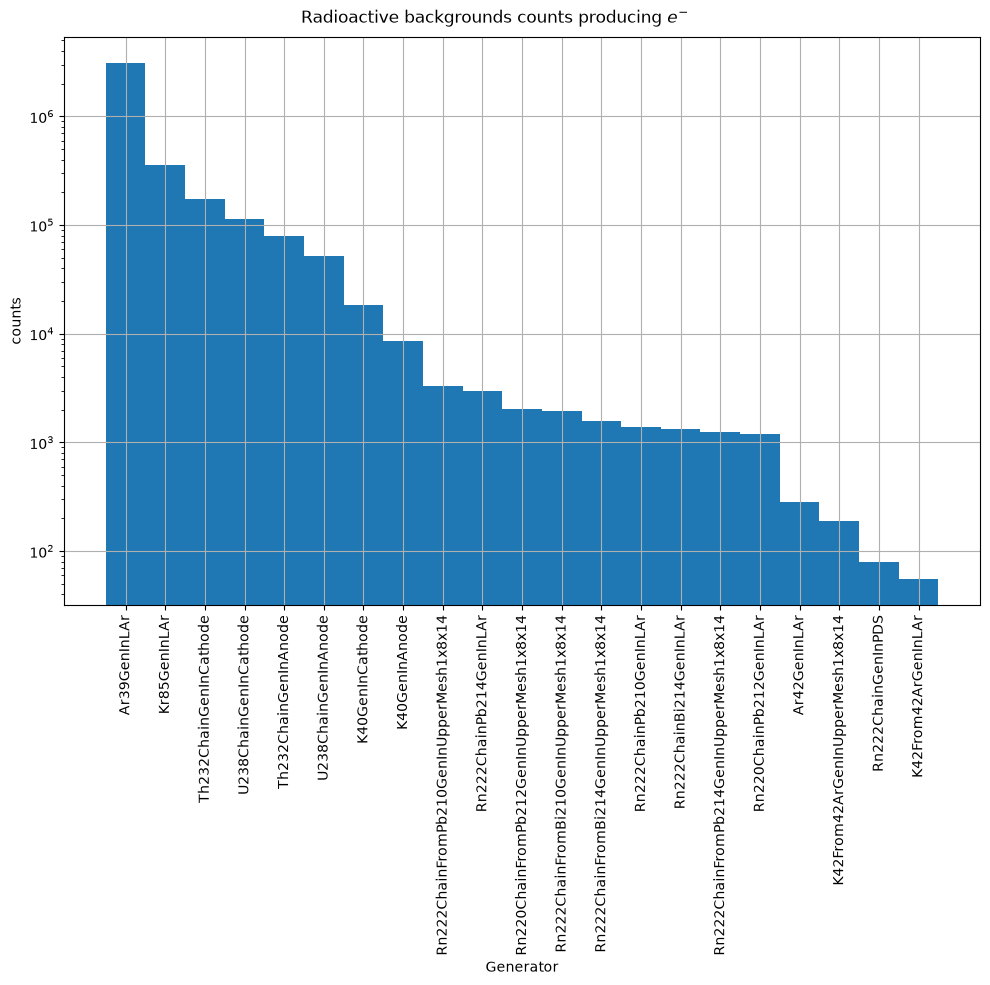

In [13]:
fig = mcp.plot_generator_activity(pdg_id=11)

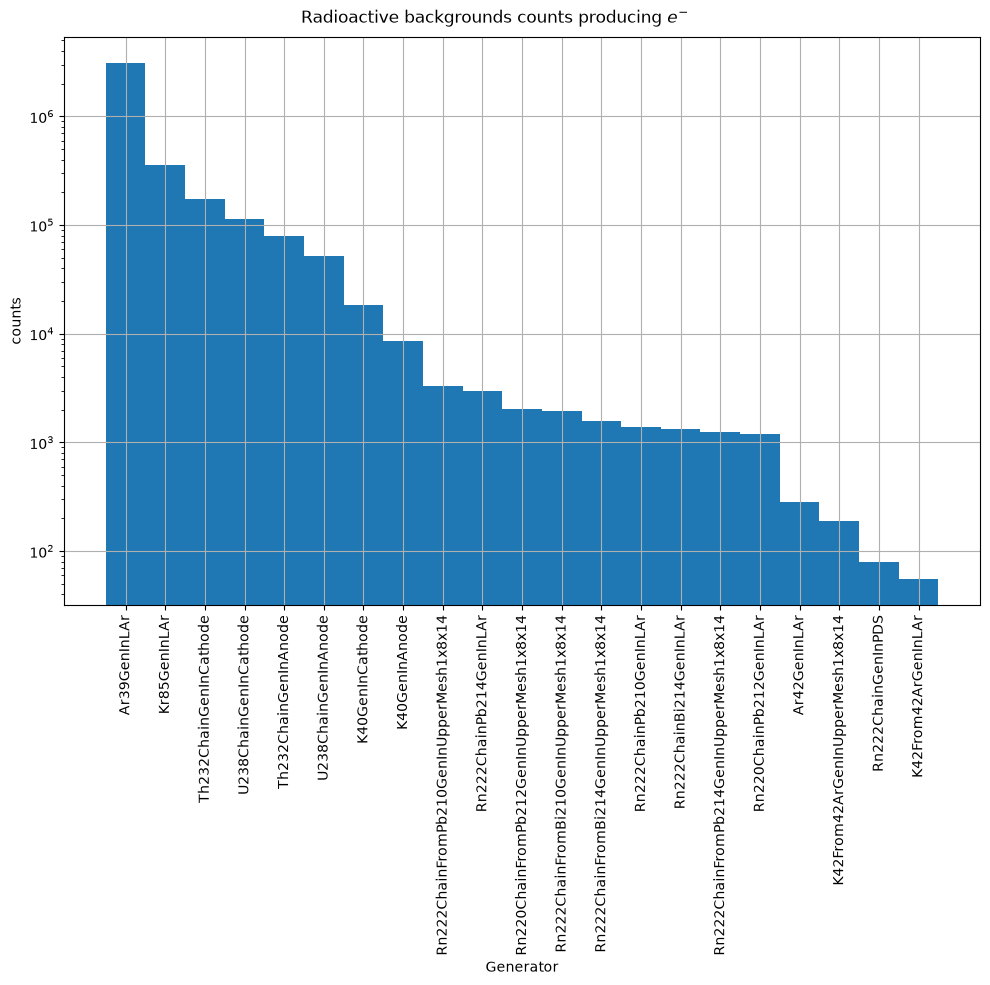

In [14]:
fig = mcp.plot_generator_activity(pdg_id=11)

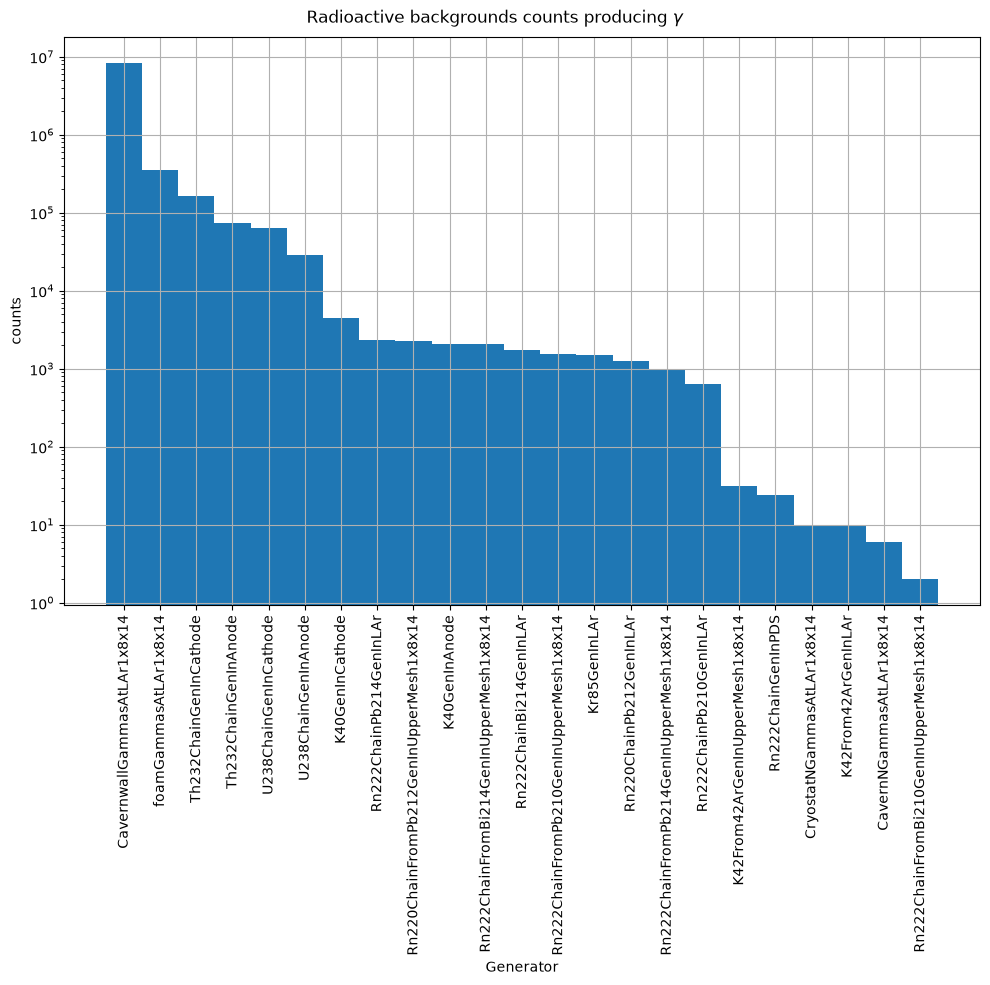

In [15]:
fig = mcp.plot_generator_activity(pdg_id=22)

## MC particles spectra

This is useful to tell the expected energy of clusters from background

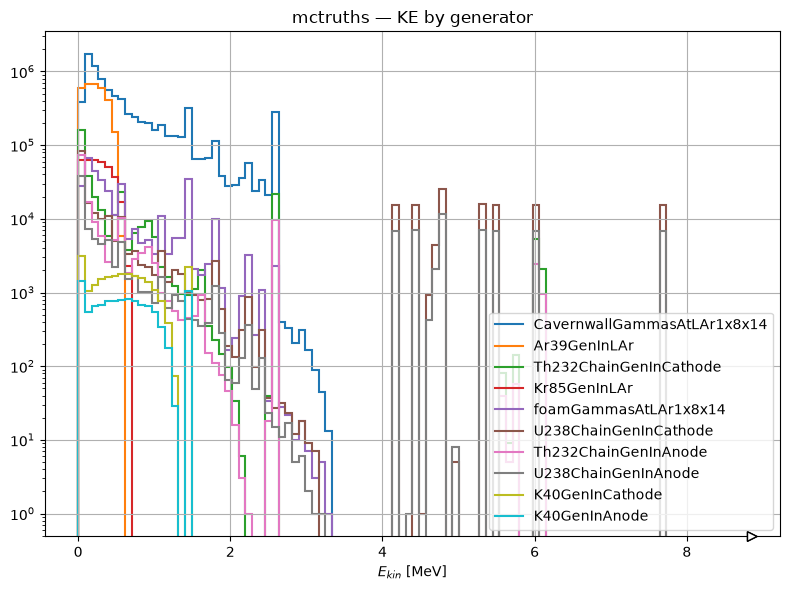

In [16]:
fig = mcp.plot_ke_spectra_by_generator(n_top=10)

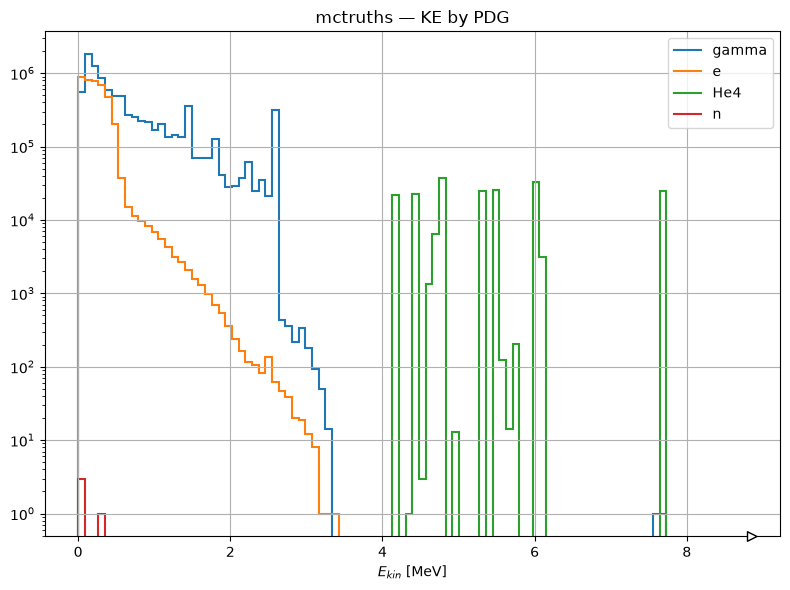

In [17]:
fig = mcp.plot_ke_spectra_by_pdg()

# Wall gammas origin checks

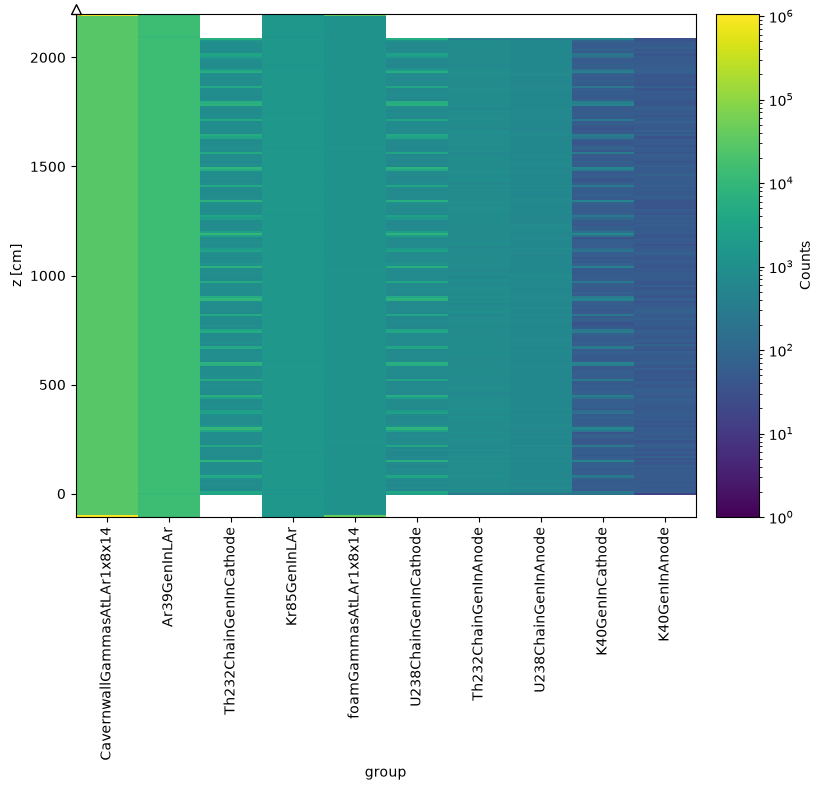

In [18]:
fig = mcp.plot_generator_origin('z', bin_width_cm=10, c_scale='log')

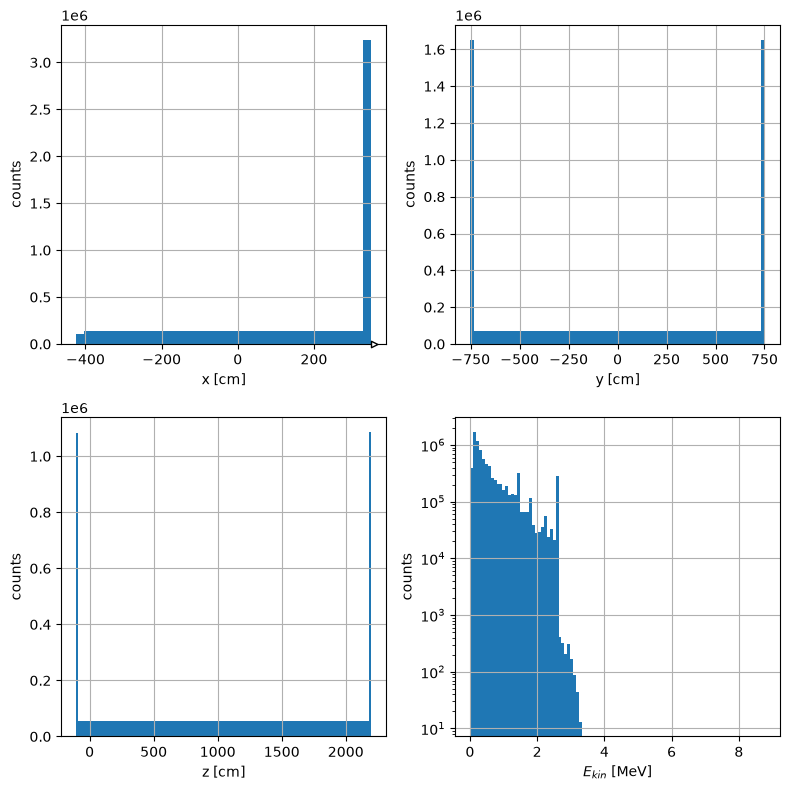

In [19]:
fig = mcp.plot_generator_pos_ke('CavernwallGammasAtLAr1x8x14')

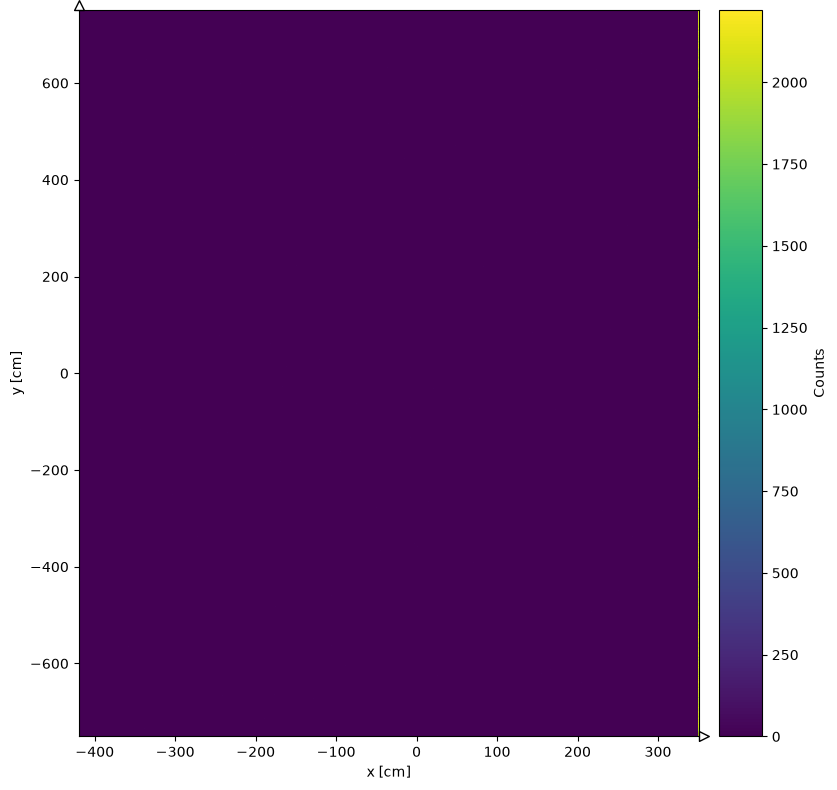

In [20]:
fig = mcp.plot_generator_2d_origin('CavernwallGammasAtLAr1x8x14', 'xy', bin_width=1)

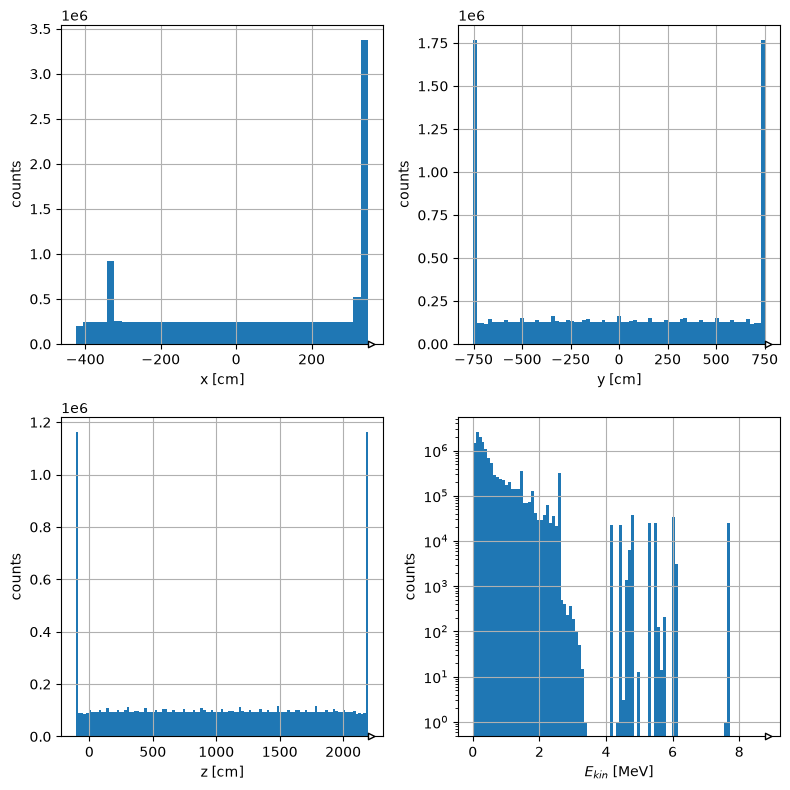

In [21]:
fig = mcp.plot_generator_pos_ke()